# CELL 1: Install & Import Libraries


In [4]:
!pip install -q nltk scikit-learn pandas matplotlib seaborn wordcloud

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(pkg, e)

print("Libraries ready.")

Libraries ready.


# CELL 2: Load Dataset

In [5]:

# Built-in sample dataset (runs out of the box) ---
sample_data = [
    ("I absolutely love the new iPhone update, it's fantastic!", "positive"),
    ("Best concert I've ever been to, what an amazing night!!", "positive"),
    ("Thank you so much for the birthday wishes everyone 😍", "positive"),
    ("This new restaurant in town is incredible, highly recommend", "positive"),
    ("Just got promoted at work! So happy right now 🎉", "positive"),
    ("The weather today is perfect for a picnic in the park", "positive"),
    ("Really impressed with the customer service today, quick and helpful", "positive"),
    ("My favorite team won the championship, unbelievable game!", "positive"),
    ("Grateful for my friends and family, life is good", "positive"),
    ("The movie exceeded all my expectations, must watch!", "positive"),
    ("I am so tired of this app crashing every single time", "negative"),
    ("Worst customer service I have ever experienced, never again", "negative"),
    ("This traffic is absolutely ridiculous, I hate my commute", "negative"),
    ("Really disappointed with the new update, it broke everything", "negative"),
    ("Can't believe they cancelled the flight with no notice", "negative"),
    ("The food was cold and the service was terrible tonight", "negative"),
    ("I'm so frustrated with my internet connection right now", "negative"),
    ("This is the worst movie I have watched all year", "negative"),
    ("Feeling really sad about the news today, heartbreaking", "negative"),
    ("Terrible experience at the store, staff was so rude", "negative"),
    ("The meeting has been rescheduled to 3pm tomorrow", "neutral"),
    ("Just finished reading the quarterly report for the team", "neutral"),
    ("The train arrives at platform 4 according to the schedule", "neutral"),
    ("Here is the link to today's webinar recording", "neutral"),
    ("The store opens at 9am and closes at 8pm on weekdays", "neutral"),
    ("I bought a new laptop yesterday for work purposes", "neutral"),
    ("The conference will be held in the main auditorium", "neutral"),
    ("Please find attached the document you requested", "neutral"),
    ("The bus route has been updated for the summer season", "neutral"),
    ("Today's forecast shows a high of 25 degrees Celsius", "neutral"),
]

df = pd.DataFrame(sample_data, columns=["text", "sentiment"])
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (30, 2)


,text,sentiment
0,"I absolutely love the new iPhone update, it's ...",positive
1,"Best concert I've ever been to, what an amazin...",positive
2,Thank you so much for the birthday wishes ever...,positive
3,"This new restaurant in town is incredible, hig...",positive
4,Just got promoted at work! So happy right now 🎉,positive


# CELL 3: Class distribution plot

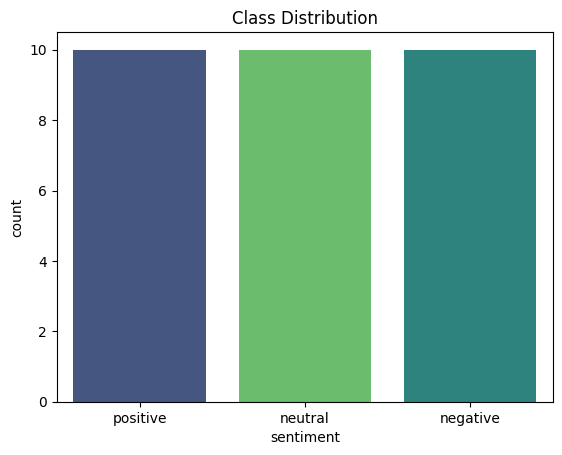

In [6]:
sns.countplot(x="sentiment", data=df, order=["positive", "neutral", "negative"], hue="sentiment", palette="viridis", legend=False)
plt.title("Class Distribution")
plt.show()

# CELL 4: Preprocessing

In [7]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# Keep negation words — dropping them flips sentiment meaning (e.g. "not good")
negations = {"no", "not", "nor", "never", "none", "n't"}
stop_words = stop_words - negations

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)      # URLs
    text = re.sub(r"@\w+", "", text)                          # mentions
    text = re.sub(r"#", "", text)                              # keep hashtag word, drop symbol
    text = re.sub(r"[^a-zA-Z\s]", "", text)                    # punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 1]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_tweet)
df[["text", "clean_text"]].head(10)

,text,clean_text
0,"I absolutely love the new iPhone update, it's ...",absolutely love new iphone update fantastic
1,"Best concert I've ever been to, what an amazin...",best concert ive ever amazing night
2,Thank you so much for the birthday wishes ever...,thank much birthday wish everyone
3,"This new restaurant in town is incredible, hig...",new restaurant town incredible highly recommend
4,Just got promoted at work! So happy right now 🎉,got promoted work happy right
5,The weather today is perfect for a picnic in t...,weather today perfect picnic park
6,Really impressed with the customer service tod...,really impressed customer service today quick ...
7,"My favorite team won the championship, unbelie...",favorite team championship unbelievable game
8,"Grateful for my friends and family, life is good",grateful friend family life good
9,"The movie exceeded all my expectations, must w...",movie exceeded expectation must watch


# CELL 5: TF-IDF + Train/Test Split

In [8]:
X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=1)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Train size: {X_train_tfidf.shape}, Test size: {X_test_tfidf.shape}")

Train size: (22, 193), Test size: (8, 193)


# CELL 6: Train models

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Naive Bayes": MultinomialNB(),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    trained_models[name] = model
    print(f"{name} — Accuracy: {acc:.2f}")

Logistic Regression — Accuracy: 0.25
Naive Bayes — Accuracy: 0.25


# CELL 7: Detailed evaluation

=== Logistic Regression ===
Accuracy: 0.25

              precision    recall  f1-score   support

    negative       0.29      1.00      0.44         2
     neutral       0.00      0.00      0.00         3
    positive       0.00      0.00      0.00         3

    accuracy                           0.25         8
   macro avg       0.10      0.33      0.15         8
weighted avg       0.07      0.25      0.11         8



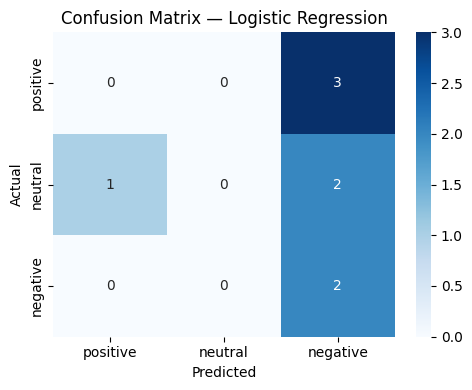

In [10]:
best_model_name = "Logistic Regression"
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test_tfidf)

print(f"=== {best_model_name} ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print(classification_report(y_test, y_pred, zero_division=0))

labels = ["positive", "neutral", "negative"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

# CELL 8: Predict on new tweets

In [11]:
def predict_sentiment(text, model=best_model, vec=vectorizer):
    cleaned = clean_tweet(text)
    vec_input = vec.transform([cleaned])
    pred = model.predict(vec_input)[0]
    proba = model.predict_proba(vec_input)[0]
    confidence = dict(zip(model.classes_, np.round(proba, 2)))
    return pred, confidence

test_tweets = [
    "I can't believe how amazing this product is, best purchase ever!",
    "This is honestly the worst service I've dealt with in years.",
    "The event starts at 6pm and ends at 9pm.",
    "Not bad at all, actually pretty decent experience overall.",
]

for tweet in test_tweets:
    sentiment, confidence = predict_sentiment(tweet)
    print(f"Tweet: {tweet}")
    print(f"  -> Predicted Sentiment: {sentiment.upper()}  |  Confidence: {confidence}\n")

Tweet: I can't believe how amazing this product is, best purchase ever!
  -> Predicted Sentiment: NEGATIVE  |  Confidence: {'negative': np.float64(0.39), 'neutral': np.float64(0.31), 'positive': np.float64(0.3)}

Tweet: This is honestly the worst service I've dealt with in years.
  -> Predicted Sentiment: NEGATIVE  |  Confidence: {'negative': np.float64(0.42), 'neutral': np.float64(0.28), 'positive': np.float64(0.31)}

Tweet: The event starts at 6pm and ends at 9pm.
  -> Predicted Sentiment: NEUTRAL  |  Confidence: {'negative': np.float64(0.28), 'neutral': np.float64(0.44), 'positive': np.float64(0.28)}

Tweet: Not bad at all, actually pretty decent experience overall.
  -> Predicted Sentiment: NEGATIVE  |  Confidence: {'negative': np.float64(0.39), 'neutral': np.float64(0.3), 'positive': np.float64(0.3)}



In [15]:
# CELL 9: Interactive prediction
user_tweet = input("Enter a tweet to analyze: ")
sentiment, confidence = predict_sentiment(user_tweet)
print(f"\nPredicted Sentiment: {sentiment.upper()}")
print(f"Confidence scores: {confidence}")

Enter a tweet to analyze: Share a quick, useful piece of advice.

Predicted Sentiment: POSITIVE
Confidence scores: {'negative': np.float64(0.31), 'neutral': np.float64(0.31), 'positive': np.float64(0.38)}


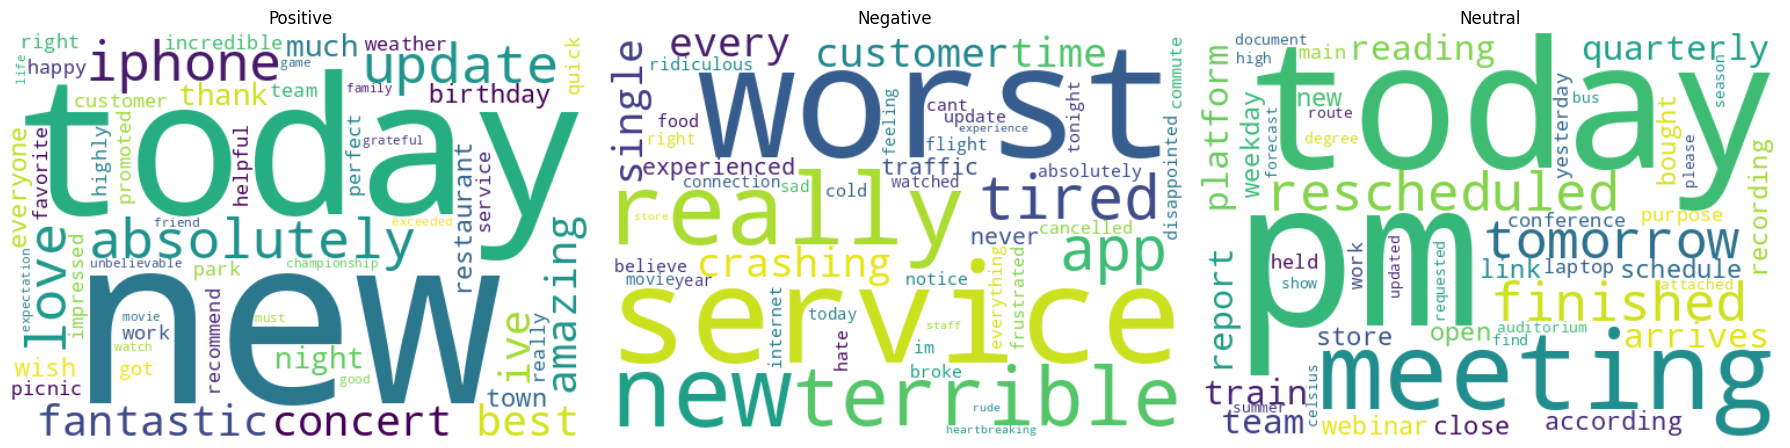

In [13]:
# CELL 10 (optional): Word clouds by sentiment
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sentiment in zip(axes, ["positive", "negative", "neutral"]):
    text = " ".join(df[df["sentiment"] == sentiment]["clean_text"])
    if text.strip():
        wc = WordCloud(width=500, height=350, background_color="white", colormap="viridis").generate(text)
        ax.imshow(wc, interpolation="bilinear")
    ax.set_title(sentiment.capitalize())
    ax.axis("off")
plt.tight_layout()
plt.show()